# BERT 임베딩 시각화 — BERT는 무엇을 "이해"하나?

**임베딩(Embedding)** 이란 단어의 의미를 숫자 벡터로 표현한 것입니다.  
의미가 비슷한 단어는 **벡터 공간에서도 가깝게** 위치합니다.

이 노트북에서 배울 것:
- BERT로 단어 임베딩 추출
- PCA로 768차원 → 2D 축소 후 시각화
- 비슷한 단어들이 군집(cluster)을 이루는 모습 확인
- 코사인 유사도 히트맵

사용 모델: `klue/bert-base`

In [1]:
# 모델과 토크나이저 로드
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = 'klue/bert-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(32000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [5]:
from tool3_2 import get_03_bert_embedding_data
import numpy as np
words, groups = get_03_bert_embedding_data()

embeddings = []
for word in words:
    inputs = tokenizer(word, return_tensors='pt')
    with torch.no_grad():
        output = model(**inputs)
    cls_emb = output.last_hidden_state[0, 0, :].numpy()
    embeddings.append(cls_emb)
embeddings = np.array(embeddings)
print(embeddings.shape)

(15, 768)


In [9]:
words = [
    ''
]

['강아지',
 '고양이',
 '토끼',
 '사자',
 '호랑이',
 '김치',
 '비빔밥',
 '삼겹살',
 '떡볶이',
 '냉면',
 '서울',
 '부산',
 '인천',
 '대구',
 '광주']

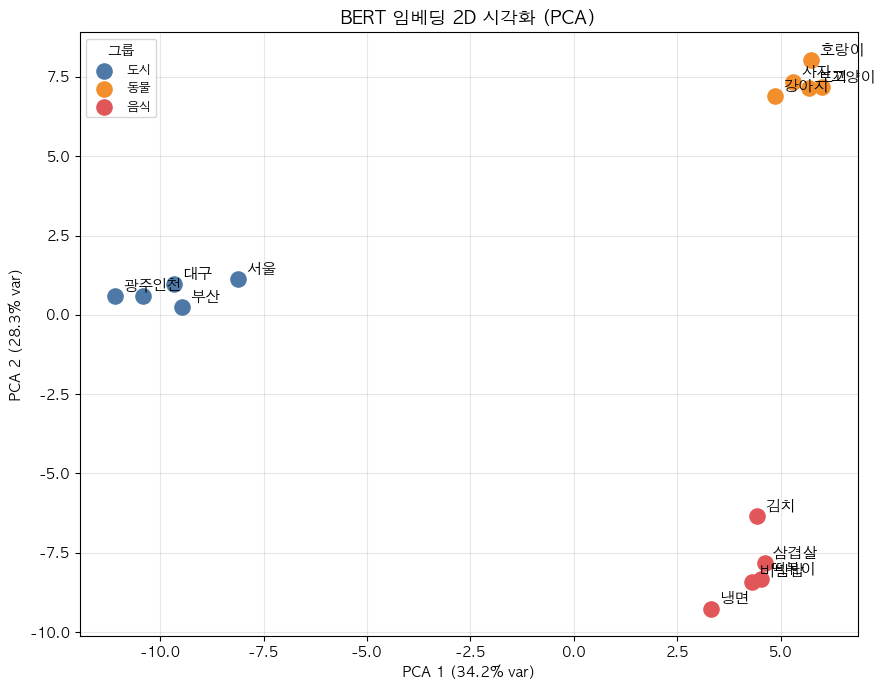

In [8]:
from sklearn.decomposition import PCA
from tool3_2 import plot_embeddings_2d
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plot_embeddings_2d(
    words,
    embeddings_2d,
    groups=groups,
    explained_variance_ratio=pca.explained_variance_ratio_,
)

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

pairs = [
    ('강아지', '고양이'),   # 동물 - 동물
    ('김치', '비빔밥'),     # 음식 - 음식
    ('서울', '부산'),       # 도시 - 도시
    ('강아지', '김치'),     # 동물 - 음식
    ('김치', '서울'),       # 음식 - 도시
]
for w1, w2 in pairs:
    i1 = words.index(w1)
    i2 = words.index(w2)
    sim = float(cosine_similarity([embeddings[i1]], [embeddings[i2]])[0][0])
    tag = '✓ 같은 그룹' if groups[i1] == groups[i2] else '✗ 다른 그룹'
    print(f'{w1:6s} ↔ {w2:6s}: {sim:.4f}  {tag}')

강아지    ↔ 고양이   : 0.9272  ✓ 같은 그룹
김치     ↔ 비빔밥   : 0.9041  ✓ 같은 그룹
서울     ↔ 부산    : 0.8658  ✓ 같은 그룹
강아지    ↔ 김치    : 0.7371  ✗ 다른 그룹
김치     ↔ 서울    : 0.6900  ✗ 다른 그룹


Sentence pair cosine similarity
------------------------------------------------------------
0-1: 0.9225  (same topic)
2-3: 0.9215  (same topic)
4-5: 0.7124  (same topic)
0-2: 0.6973  (different topic)
2-4: 0.6055  (different topic)


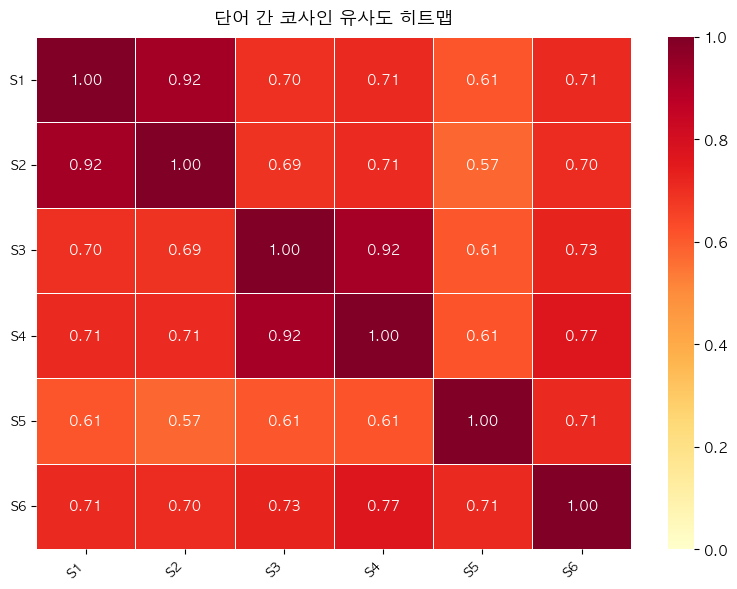


Sentence key:
S1: 강아지가 공원에서 신나게 뛰어놀고 있어요.
S2: 고양이가 창가에서 햇볕을 쬐며 쉬고 있어요.
S3: 김치찌개에 두부를 넣고 저녁을 준비했어요.
S4: 비빔밥에 고추장을 넣어 맛있게 먹었어요.
S5: 서울 도심의 출근길 지하철이 매우 붐볐어요.
S6: 부산 해운대 해변은 주말이라 사람이 많았어요.


In [12]:
# Sentence-level embedding test with BERT [CLS]
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def get_cls_embedding(text: str) -> np.ndarray:
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=64)
    with torch.no_grad():
        output = model(**inputs)
    return output.last_hidden_state[0, 0, :].numpy()


sentences = [
    '강아지가 공원에서 신나게 뛰어놀고 있어요.',
    '고양이가 창가에서 햇볕을 쬐며 쉬고 있어요.',
    '김치찌개에 두부를 넣고 저녁을 준비했어요.',
    '비빔밥에 고추장을 넣어 맛있게 먹었어요.',
    '서울 도심의 출근길 지하철이 매우 붐볐어요.',
    '부산 해운대 해변은 주말이라 사람이 많았어요.',
]

sentence_groups = ['animal', 'animal', 'food', 'food', 'city', 'city']
sentence_embeddings = np.array([get_cls_embedding(s) for s in sentences])
sentence_sim_matrix = cosine_similarity(sentence_embeddings)

print('Sentence pair cosine similarity')
print('-' * 60)
compare_pairs = [
    (0, 1),  # same: animal
    (2, 3),  # same: food
    (4, 5),  # same: city
    (0, 2),  # different: animal vs food
    (2, 4),  # different: food vs city
]

for i, j in compare_pairs:
    sim = float(sentence_sim_matrix[i, j])
    tag = 'same topic' if sentence_groups[i] == sentence_groups[j] else 'different topic'
    print(f'{i}-{j}: {sim:.4f}  ({tag})')

# Heatmap with short labels for readability
labels = [f'S{i+1}' for i in range(len(sentences))]
from tool3_2 import plot_similarity_heatmap
plot_similarity_heatmap(labels, sentence_sim_matrix)

print('\nSentence key:')
for idx, sent in enumerate(sentences, start=1):
    print(f'S{idx}: {sent}')